# Time Series Analysis & Forecasting for Multiple Humidity Sensors in a Warehouse (SARIMA)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

In [45]:
def adf_test_results(combined_df):
    result = adfuller(combined_df.dropna()) # dropna() to handle potential missing values
    return {
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Critical Values': result[4],
        'is_stationary': result[1] < 0.05 # Check p-value against 0.05
    }

In [46]:
file_path = r"C:\\Users\\sulaiman.at\\Documents\\GitHub\\TSA&F-Humidity-Warehouse\\RawData1.xls"
# Load the data
data = pd.read_excel(file_path, engine="xlrd", sheet_name=None) # Load all sheets into a dictionary

# Combine sheets (assuming common date column)
combined_df = pd.DataFrame()
for sheet_name, df in data.items():
    df['SourceSheet'] = sheet_name # Optional: track source
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Set the date column as the index
combined_df['Date'] = pd.to_datetime(combined_df['Time'])
combined_df.set_index('Date', inplace=True)

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


In [47]:
combined_df.head()

,Index,Time,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%),SourceSheet
Date,,,,,,,,,
2025-02-27 10:04:44,1,02/27/2025 10:04:44 AM,80.21,78.64,76.12,77.16,78.87,78.25,sheet1
2025-02-27 10:04:46,2,02/27/2025 10:04:46 AM,80.19,78.64,76.12,77.16,78.88,78.26,sheet1
2025-02-27 10:04:48,3,02/27/2025 10:04:48 AM,80.21,78.65,76.10,77.14,78.87,78.24,sheet1
2025-02-27 10:04:50,4,02/27/2025 10:04:50 AM,80.06,78.64,76.12,77.17,78.87,78.12,sheet1
2025-02-27 10:04:52,5,02/27/2025 10:04:52 AM,80.06,78.64,76.12,77.18,78.88,78.12,sheet1


In [48]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 302401 entries, 2025-02-27 10:04:44 to 2025-03-06 10:04:44
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Index        302401 non-null  int64  
 1   Time         302401 non-null  str    
 2   CH01(%)      302401 non-null  float64
 3   CH02(%)      302401 non-null  float64
 4   CH03(%)      302401 non-null  float64
 5   CH04(%)      302401 non-null  float64
 6   CH05(%)      302401 non-null  float64
 7   CH06(%)      302401 non-null  float64
 8   SourceSheet  302401 non-null  str    
dtypes: float64(6), int64(1), str(2)
memory usage: 23.1 MB


In [49]:

# Convert Time column from string to datetime
combined_df['Time'] = pd.to_datetime(combined_df['Time'], format='mixed')

# Set Time as index for time series analysis
combined_df = combined_df.set_index('Time')


In [50]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 302401 entries, 2025-02-27 10:04:44 to 2025-03-06 10:04:44
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Index        302401 non-null  int64  
 1   CH01(%)      302401 non-null  float64
 2   CH02(%)      302401 non-null  float64
 3   CH03(%)      302401 non-null  float64
 4   CH04(%)      302401 non-null  float64
 5   CH05(%)      302401 non-null  float64
 6   CH06(%)      302401 non-null  float64
 7   SourceSheet  302401 non-null  str    
dtypes: float64(6), int64(1), str(1)
memory usage: 20.8 MB


In [51]:
combined_df.index.is_monotonic_increasing

# If returns False, sort the index
# combined_df = combined_df.sort_index()

True

In [52]:
# Remove impossible humidity values
combined_df = combined_df.replace(-32640, pd.NA)

# Drop rows where all channels are missing
combined_df = combined_df.dropna(how='all')

# Drop the source sheet column if it exists
combined_df = combined_df.drop(columns=['SourceSheet'], errors='ignore') 

In [53]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 302401 entries, 2025-02-27 10:04:44 to 2025-03-06 10:04:44
Data columns (total 7 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Index    302401 non-null  int64  
 1   CH01(%)  302401 non-null  float64
 2   CH02(%)  302401 non-null  float64
 3   CH03(%)  302401 non-null  float64
 4   CH04(%)  302401 non-null  float64
 5   CH05(%)  302401 non-null  float64
 6   CH06(%)  302401 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 18.5 MB


In [54]:
combined_df.head()

,Index,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%)
Time,,,,,,,
2025-02-27 10:04:44,1,80.21,78.64,76.12,77.16,78.87,78.25
2025-02-27 10:04:46,2,80.19,78.64,76.12,77.16,78.88,78.26
2025-02-27 10:04:48,3,80.21,78.65,76.10,77.14,78.87,78.24
2025-02-27 10:04:50,4,80.06,78.64,76.12,77.17,78.87,78.12
2025-02-27 10:04:52,5,80.06,78.64,76.12,77.18,78.88,78.12


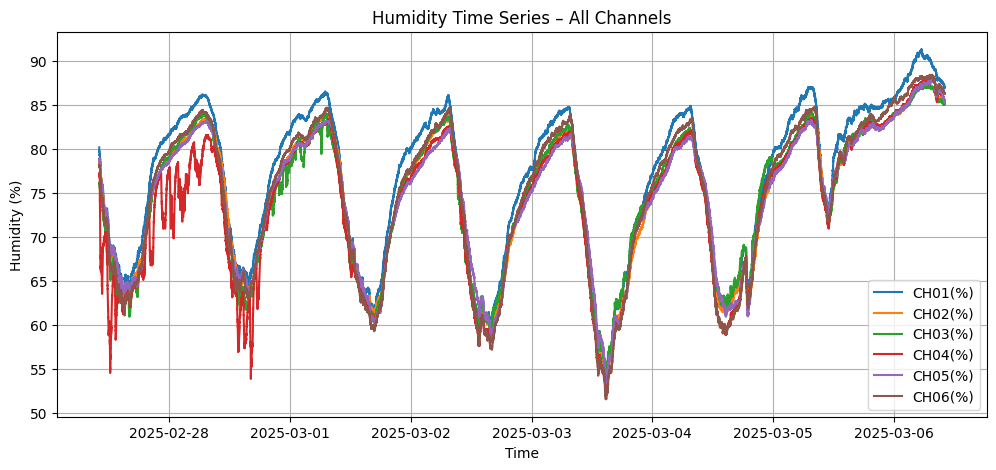

In [55]:

# Convert all columns to numeric and coerce errors to NaN (in case there are any non-numeric values)
combined_df = combined_df.apply(pd.to_numeric, errors='coerce')

# Drop the non-sensor column if it exists
combined_df = combined_df.drop(columns=['Index'], errors='ignore')

plt.figure(figsize=(12,5))
for col in combined_df.columns:
    plt.plot(combined_df.index, combined_df[col], label=col)

plt.title("Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Perform ADF test for each channel
for column in combined_df.columns:
    print(f"ADF Test for {column}:")
    result = adfuller(combined_df[column].dropna()) # dropna() to handle potential missing values
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print(f"Critical Values: {result[4]}")
    print(f"Is Stationary: {result[1] < 0.05}\n")

ADF Test for CH01(%):
ADF Statistic: -0.6642239954223339
p-value: 0.8558000162583135
Critical Values: {'1%': np.float64(-3.4303716312192623), '5%': np.float64(-2.8615495607305257), '10%': np.float64(-2.5667750888300187)}
Is Stationary: False

ADF Test for CH02(%):
ADF Statistic: -0.35346581325119103
p-value: 0.9175832143206506
Critical Values: {'1%': np.float64(-3.4303716312192623), '5%': np.float64(-2.8615495607305257), '10%': np.float64(-2.5667750888300187)}
Is Stationary: False

ADF Test for CH03(%):
ADF Statistic: -0.7378259065304781
p-value: 0.8367070336832008
Critical Values: {'1%': np.float64(-3.4303716282859678), '5%': np.float64(-2.8615495594340503), '10%': np.float64(-2.566775088139951)}
Is Stationary: False

ADF Test for CH04(%):
ADF Statistic: -1.5092257379995258
p-value: 0.528942661698936
Critical Values: {'1%': np.float64(-3.4303716311477093), '5%': np.float64(-2.8615495606989003), '10%': np.float64(-2.5667750888131855)}
Is Stationary: False

ADF Test for CH05(%):
ADF Sta

**Remove the trend**

In [57]:
first_diff = combined_df.diff()
first_diff.dropna(inplace=True)

C:\Users\sulaiman.at\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


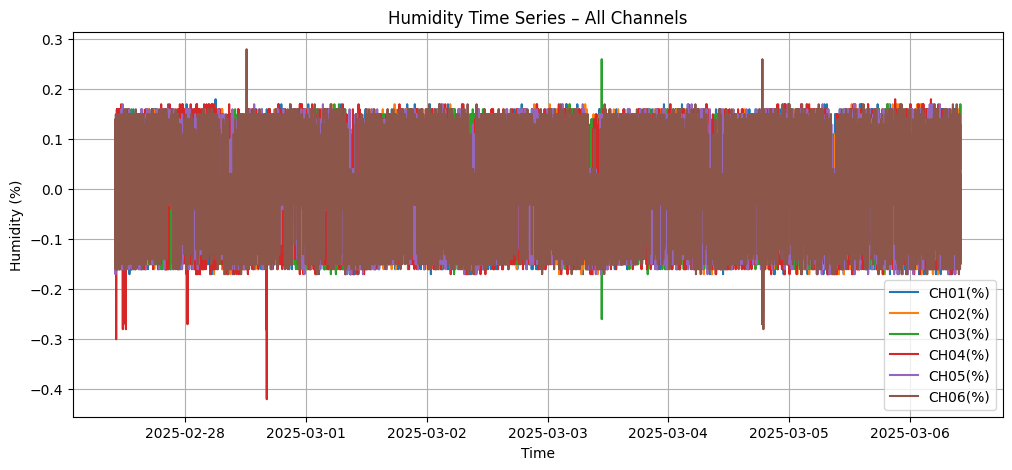

In [58]:
plt.figure(figsize=(12,5))
for col in first_diff.columns:
    plt.plot(first_diff.index, first_diff[col], label=col)

plt.title("Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()


ADF Test for CH01(%):
ADF Statistic: -42.082282067795134
p-value: 0.0
Critical Values: {'1%': np.float64(-3.430371631290816), '5%': np.float64(-2.8615495607621515), '10%': np.float64(-2.566775088846852)}
Is Stationary: True

ADF Test for CH02(%):
ADF Statistic: -42.484836511257654
p-value: 0.0
Critical Values: {'1%': np.float64(-3.430371631290816), '5%': np.float64(-2.8615495607621515), '10%': np.float64(-2.566775088846852)}
Is Stationary: True

ADF Test for CH03(%):
ADF Statistic: -66.87279991460801
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4303716282859678), '5%': np.float64(-2.8615495594340503), '10%': np.float64(-2.566775088139951)}
Is Stationary: True

ADF Test for CH04(%):
ADF Statistic: -41.43401682534711
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4303716311477093), '5%': np.float64(-2.8615495606989003), '10%': np.float64(-2.5667750888131855)}
Is Stationary: True

ADF Test for CH05(%):
ADF Statistic: -42.067937466957126
p-value: 0.0
Critical Values: {'1%': np.fl

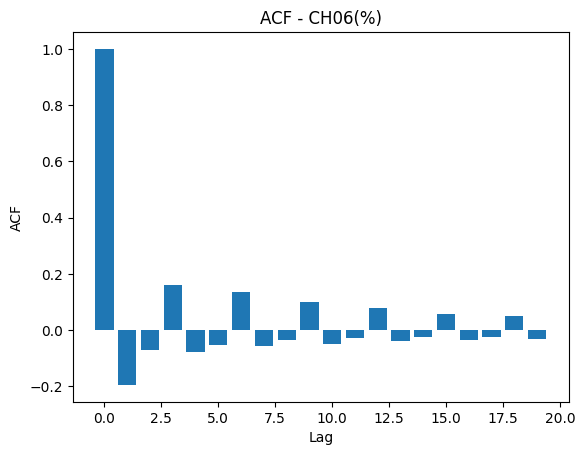

In [59]:
# Perform ADF test for each channel on first difference
for column in first_diff.columns:
    print(f"ADF Test for {column}:")
    result = adfuller(first_diff[column].dropna()) # dropna() to handle potential missing values
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print(f"Critical Values: {result[4]}")
    print(f"Is Stationary: {result[1] < 0.05}\n")

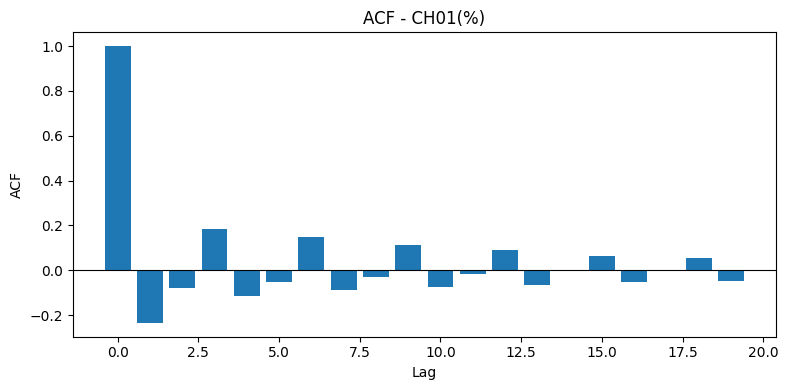

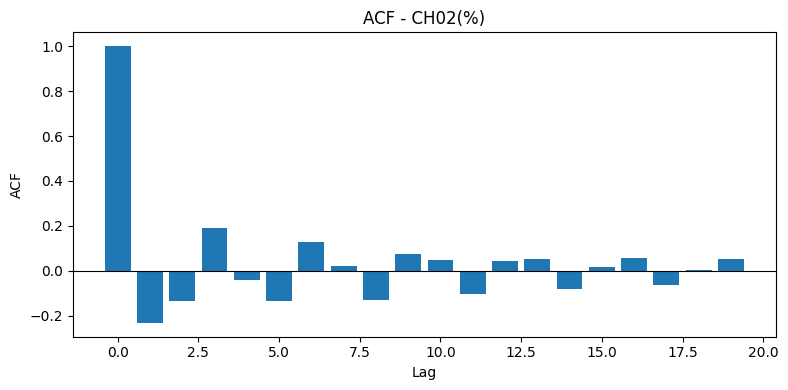

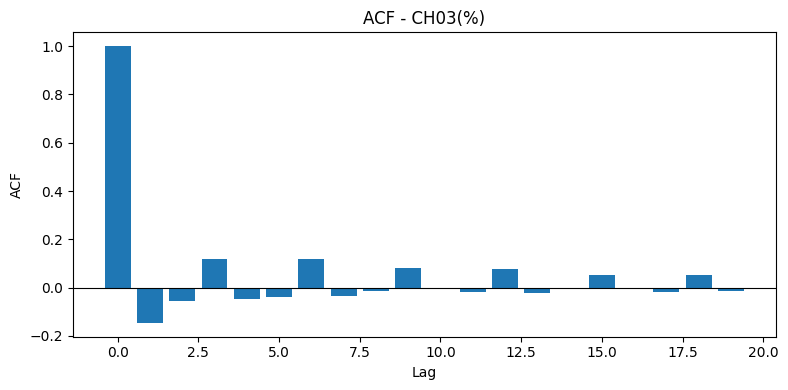

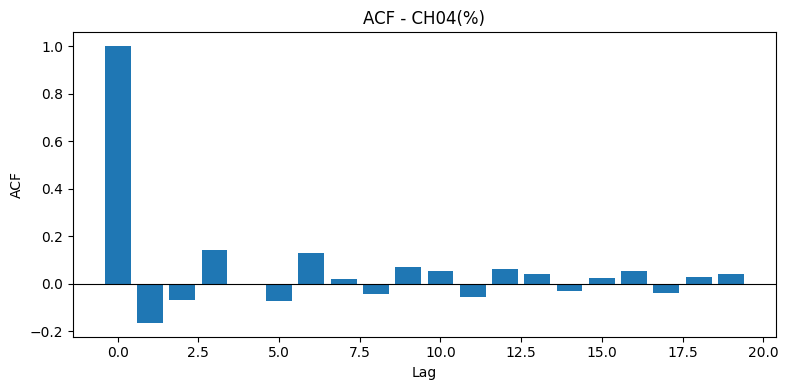

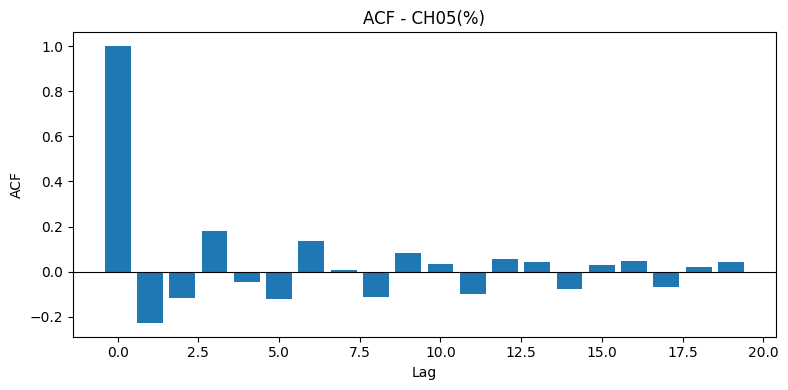

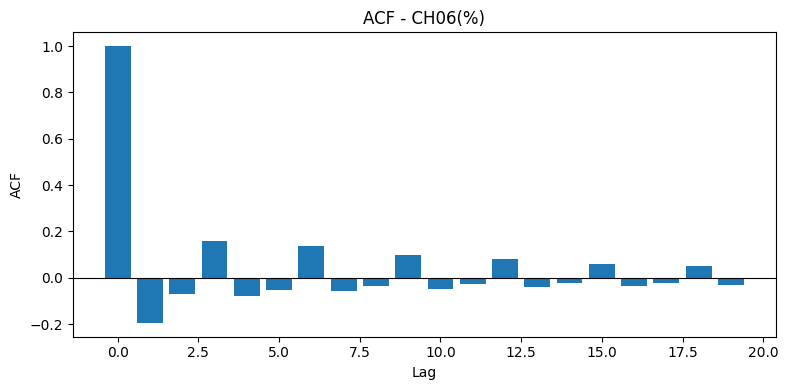

In [67]:
num_lags = 20

for col in first_diff.columns:
    series = first_diff[col].dropna()
    if len(series) < 2:
        print(f"Skipping {col}: not enough data")
        continue

    acf_vals = acf(series, nlags=num_lags-1)

    plt.figure(figsize=(8, 4))
    plt.bar(range(num_lags), acf_vals[:num_lags])
    plt.axhline(0, color="black", linewidth=0.8)
    plt.title(f"ACF - {col}")
    plt.xlabel("Lag")
    plt.ylabel("ACF")
    plt.tight_layout()
    plt.show()


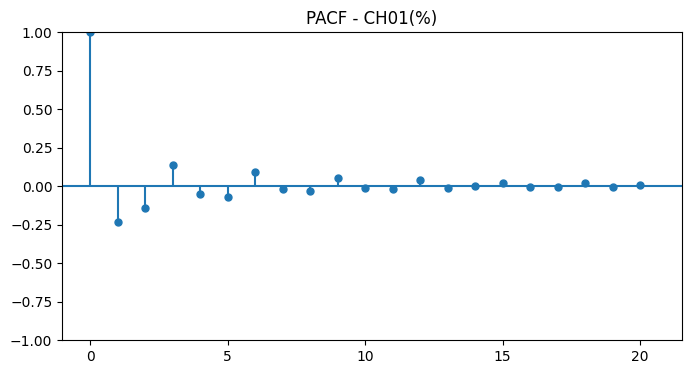

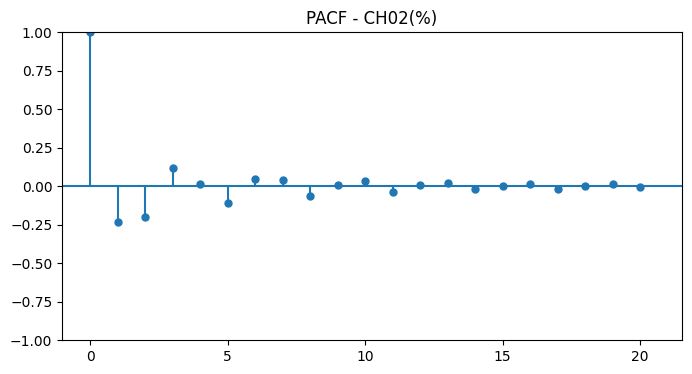

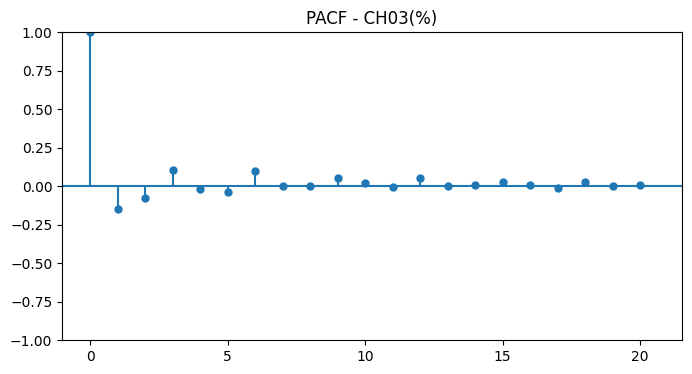

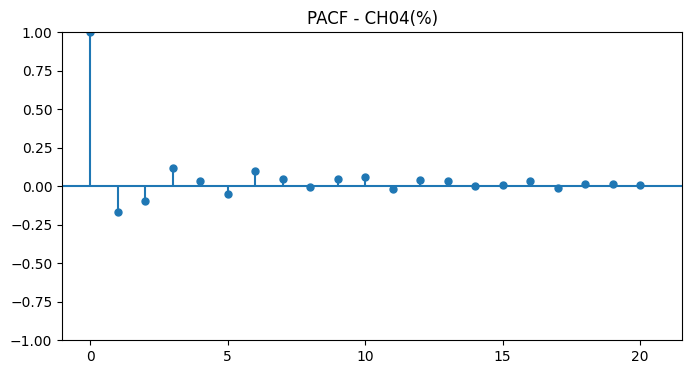

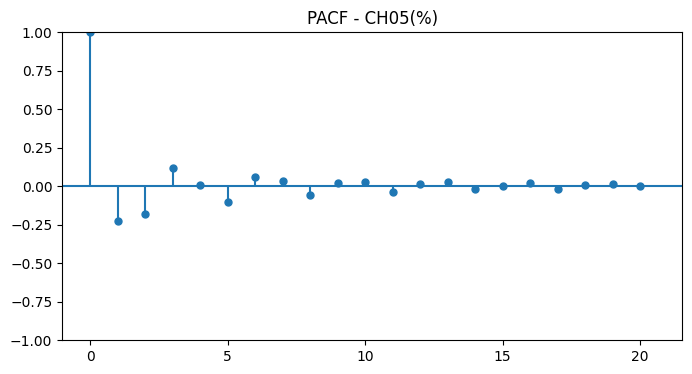

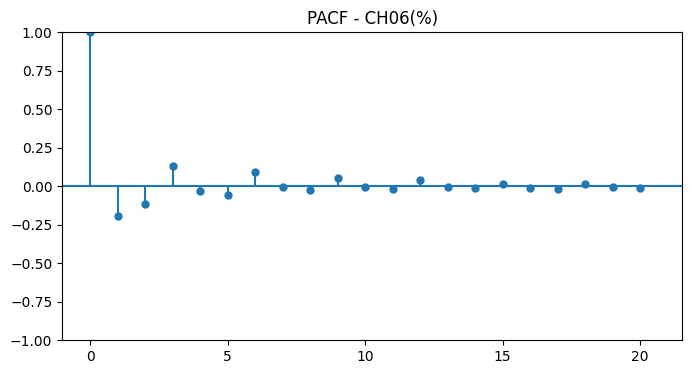

In [60]:
for column in first_diff.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_pacf(first_diff[column].dropna(), lags=20, ax=ax, title=f'PACF - {column}')
    plt.show()

In [61]:
# Choose one channel
y = first_diff['CH04(%)'].copy()

# Ensure numeric and handle error codes
y = pd.to_numeric(y, errors='coerce').replace(-32640, np.nan)

# Sort time
y = y.sort_index()

# Align timestamps to nearest 30 minutes and aggregate duplicates
y.index = y.index.round('30min')
y = y.groupby(level=0).mean()

# Enforce strict 30-min frequency
y = y.asfreq('30min')

# Fill small gaps (safe for short-term forecasting)
y = y.interpolate('time').ffill().bfill()

# Train/test split
split = int(len(y) * 0.8)
train = y.iloc[:split]
test  = y.iloc[split:]  

In [62]:

model = pm.auto_arima(
    train,
    seasonal=False,        
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-2475.986, Time=0.30 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-2456.285, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-2459.038, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-2457.741, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-2457.552, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-2450.283, Time=0.08 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=-2514.291, Time=0.37 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-2503.968, Time=0.06 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=-2505.076, Time=0.38 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=-2515.109, Time=0.15 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-2519.945, Time=0.26 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-2510.619, Time=0.14 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=-2519.812, Time=0.28 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=-2510.418, Time=0.19 sec
 ARIMA(3,0,4)(0,0,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  269
Model:               SARIMAX(2, 0, 3)   Log Likelihood                1265.973
Date:                Tue, 31 Mar 2026   AIC                          -2519.945
Time:                        17:03:02   BIC                          -2498.377
Sample:                    02-27-2025   HQIC                         -2511.283
                         - 03-05-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1712      0.070      2.457      0.014       0.035       0.308
ar.L2          0.4423      0.073      6.040      0.000       0.299       0.586
ma.L1         -0.0319      0.090     -0.354      0.724      -0.208       0.145
ma.L2         -0.4684      0.071     -6.610      0.000      -0.607      -0.330
ma.L3          0.3393      0.062      5.471      0.000       0.218       0.461
sigma2      4.756e-06   2.54e-07     18.693      0.000    4.26e-06    5.25e-06
===================================================================================
Ljung-Box (L1) (Q):                   0.47   Jarque-Bera (JB):               877.49
Prob(Q):                              0.50   Prob(JB):                         0.00
Heteroskedasticity (H):               0.16   Skew:                             0.08
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.85
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

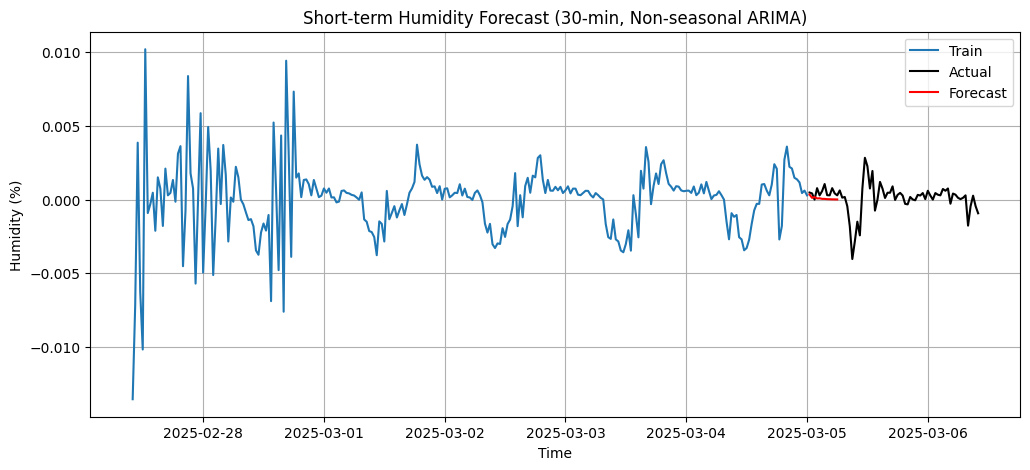

In [63]:

n_periods = 12
forecast = model.predict(n_periods=n_periods)

forecast_index = pd.date_range(start=test.index[0], periods=n_periods, freq='30min')
forecast_series = pd.Series(forecast, index=forecast_index)

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(forecast_series.index, forecast_series, label="Forecast", color="red")
plt.title("Short-term Humidity Forecast (30-min, Non-seasonal ARIMA)")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.grid(True)
plt.legend()
plt.show()


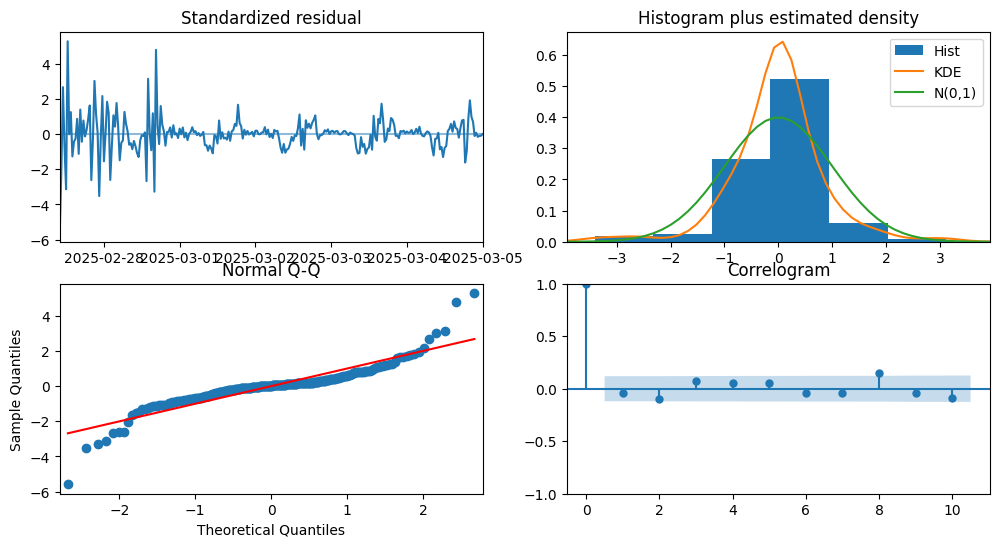

In [64]:
model.plot_diagnostics(figsize=(12,6))
plt.show()


In [65]:

simple_model = pm.ARIMA(order=(1,0,1), with_intercept=True)
simple_model.fit(train)


n_periods = 12

# Complex model forecast
fc_complex = model.predict(n_periods=n_periods)

# Simple model forecast
fc_simple = simple_model.predict(n_periods=n_periods)
                                 
                                 
actual = test.iloc[:n_periods]

mae_complex = mean_absolute_error(actual, fc_complex)
mae_simple  = mean_absolute_error(actual, fc_simple)

print("Complex ARIMA(2,0,4) MAE:", mae_complex)
print("Simple  ARIMA(1,0,1) MAE:", mae_simple)



Complex ARIMA(2,0,4) MAE: 0.00041784933914723886
Simple  ARIMA(1,0,1) MAE: 0.0005069417876820196


c:\Users\sulaiman.at\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\sulaiman.at\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


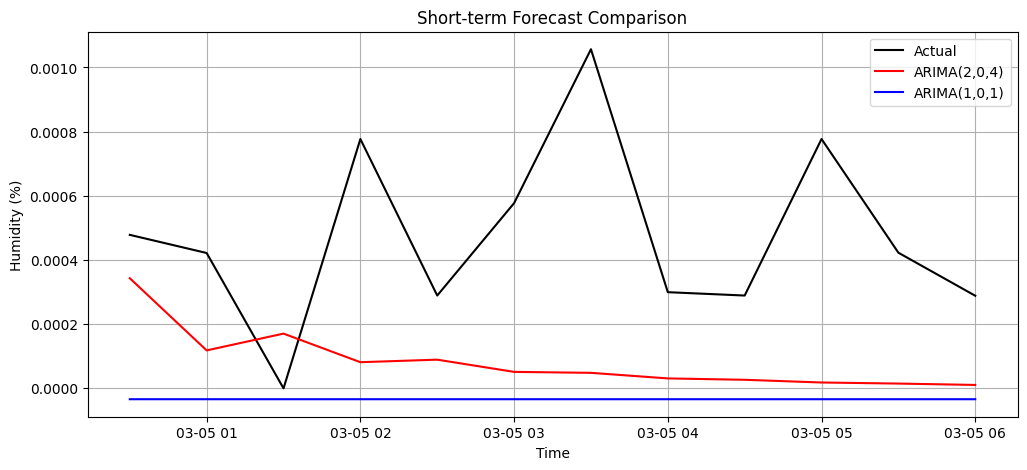

In [66]:

plt.figure(figsize=(12,5))
plt.plot(test.index[:n_periods], actual, label="Actual", color="black")
plt.plot(test.index[:n_periods], fc_complex, label="ARIMA(2,0,4)", color="red")
plt.plot(test.index[:n_periods], fc_simple, label="ARIMA(1,0,1)", color="blue")

plt.title("Short-term Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()
